#####**Observação:** É necessário carregar todos resultados do task1.*csvs, e benchmark do experiment 1

#**Benchmark & Pipeline ML — NYC Taxi**
####Trabalho realizado para disciplina de Ciência de Dados em Larga Escala
#####**Grupo:** Renata Azevedo (up202512262), Giuliano (up202512089) e Ni (up202205842)


---
5.   **Experimento 2 -  Adição do Modin ao benchmark**

Substitui o Pandas com `import modin.pandas as mpd`.

O seu principal objetivo é acelerar operações Pandas sem necessidade de alteração de código, utilizando motores de execução paralela como Ray ou Dask.

É esperado ser eficaz em workloads médias não justificam Spark, mas beneficiam de paralelização automática em múltiplos núcleos, mas não para leitura de datasets de pequena ou dimensão.

>5.1.   **Configuração do Ambiente**


Instalação da biblioteca de processamento de dados chamada Modin, configurada especificamente para usar o Ray como motor de computação paralela:



In [1]:
# ============================================================
# INSTALAÇÕES — execute apenas uma vez no Colab
# Descomente as linhas necessárias e volte a comentar após instalar
# ============================================================

!pip install modin[ray]                      # Modin (backend Ray)

print("OK.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.4 MB/s eta 0:00:00
OK.


Iniciando a leitura com algumas importações necessárias:

In [2]:
#============================================================
# IMPORTS GERAIS
# ============================================================
import os, time, warnings, urllib.request, gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Data    : {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Pandas  : 2.2.2
NumPy   : 2.0.2
Data    : 2026-06-03 20:19


In [3]:
# ============================================================
# IMPORTS DAS BIBLIOTECAS BIG DATA
# try/except: o notebook não quebra se uma lib não estiver instalada
# ============================================================

# Injeta dicionário vazio para compatibilidade do Spark com Pandas recente
if not hasattr(pd.core.common, '_builtin_table'):
    pd.core.common._builtin_table = {}

    DASK_AVAILABLE = False

# --- Modin (Ray como backend default) ---
# [ADICIONADO] — Modin não estava no notebook original
try:
    import modin.pandas as mpd
    import modin
    print(f" Modin       : {modin.__version__}")
    MODIN_AVAILABLE = True
except ImportError:
    print(" Modin não disponível (pip install modin[ray])")
    MODIN_AVAILABLE = False
import ray


if ray.is_initialized():
    ray.shutdown()

# Força o Ray a respeitar os limites apertados do Colab gratuito
ray.init(
    num_cpus=2,                     # O Colab gratuito só tem 2 vCPUs
    object_store_memory=2 * 1024 * 1024 * 1024, # Limita o cache do Ray a 2 GB (evita estouro)
    _memory=4 * 1024 * 1024 * 1024  # Limita a memória de trabalho a 4 GB
)


# --- Scikit-learn ---
try:
    import sklearn
    print(f" Scikit-learn: {sklearn.__version__}")
except ImportError:
    print(" Scikit-learn não disponível")

 Modin       : 0.37.1


2026-06-03 20:19:45,809	INFO worker.py:2012 -- Started a local Ray instance.


 Scikit-learn: 1.6.1


In [4]:
# ============================================================
# CONFIGURAÇÃO GLOBAL
# Altere apenas estas variáveis para escalar o experimento
# ============================================================

ANO       = 2026   # Ano dos dados NYC Taxi
NUM_MESES = 2      # Número de meses a descarregar (1 = ~61 MB; 12 = ~730 MB)
caminho   = Path("./FileStore/taxi/csv2026")  # Pasta local dos dados

caminho.mkdir(parents=True, exist_ok=True)
print(f" Pasta: {caminho.resolve()}")
print(f" Período: {ANO}, meses 1 a {NUM_MESES}")

 Pasta: /content/FileStore/taxi/csv2026
 Período: 2026, meses 1 a 2


In [5]:
# Lista os ficheiros se a pasta existir
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        for f in ficheiros:
            print(f.name)
    else:
        print("A pasta está vazia.")
else:
    print("A pasta ainda não foi criada.")

A pasta está vazia.


In [6]:
opener = urllib.request.build_opener()
opener.addheaders = [
    ('User-Agent',
     'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36')
]
urllib.request.install_opener(opener)

In [7]:
# ============================================================
# DOWNLOAD AUTOMÁTICO DOS FICHEIROS PARQUET
# Parquet é um formato colunar — muito mais eficiente que CSV
# para as leituras parciais que o Dask/Spark fazem.
# ============================================================

url_loc = {} # Mapeia a URL de download para o caminho do ficheiro



for year in range(2026, 2027):
    for m in range(1, 3):
        month = "{:02d}".format(m)

        # 1. URL dinâmica com base nas variáveis do loop (Aponta para o .parquet real de cada mês)
        url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month}.parquet"

        # 2. Nome do ficheiro local atualizado para refletir a extensão correta (.parquet)
        fname = f"yellow_tripdata_{year}-{month}.parquet"

        # Como está no Windows (caminho atual), o destino aponta para a pasta local criada
        loc = f"./FileStore/taxi/csv2026/{fname}"

        # Guarda no dicionário
        url_loc[url] = loc

In [8]:
# 3. Executa o loop de download corrigido
for url, loc in url_loc.items():
    if Path(loc).exists():
        mb = Path(loc).stat().st_size / 1e6
        print(f" Já existe: {Path(loc).name} ({mb:.1f} MB)")
        continue
    try:
        print(f"⬇  A descarregar: {url} ...")
        urllib.request.urlretrieve(url, loc)
        mb = Path(loc).stat().st_size / 1e6
        print(f"   Guardado: {mb:.1f} MB")
    except Exception as e:
        print(f" Erro: {e}")

print("Processo de download concluído!")


⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet ...
   Guardado: 64.2 MB
⬇  A descarregar: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-02.parquet ...
   Guardado: 58.7 MB
Processo de download concluído!


5.2   **Início das Operações**


---
>5.2.1  **Task 1 — Leitura dos Dados (*Reading*)**

| Estratégia | Biblioteca | Comportamento |
|---|---|---|
| **Eager** | Modin | Carrega tudo na RAM imediatamente |

In [9]:
resultados = []   # lista global: (operação, biblioteca, tempo_s)

In [10]:
def benchmark(name, func):
    start = time.time()
    result = func()
    end = time.time()

    print(f"{name}: {end - start:.4f} sec")
    return result

In [11]:
def benchmark_pandas(folder_path: Path):
    print("Iniciando leitura com Pandas...")

    start = time.perf_counter()

    dfs = []
    for f in folder_path.glob("*.parquet"):
        dfs.append(pd.read_parquet(f))

    df = pd.concat(dfs, ignore_index=True)

    elapsed = time.perf_counter() - start

    print("\nResultado Pandas:")
    print(f"- Linhas: {len(df)}")
    print(f"- Colunas: {df.shape[1]}")
    print(f"- Tempo: {elapsed:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Pandas', round(elapsed, 4)))  # substitui com o valor real
    return df, elapsed

In [12]:
# Define o caminho da pasta local onde os ficheiros estão a ser guardados
caminho = Path("./FileStore/taxi/csv2026")

# Lista o conteúdo da pasta
if caminho.exists():
    ficheiros = list(caminho.iterdir())
    if ficheiros:
        print(f"Encontrados {len(ficheiros)} ficheiro(s):")
        for f in ficheiros:
            print(f"- {f.name}")
    else:
        print("A pasta está vazia. Precisa de executar o loop de download primeiro!")
else:
    print("A pasta ainda não existe no caminho atual.")

Encontrados 2 ficheiro(s):
- yellow_tripdata_2026-02.parquet
- yellow_tripdata_2026-01.parquet


**Leitura de dados com a biblioteca Modin:**

In [13]:
# ── Task 1D: Modin  ──
# Modin usa a mesma API do Pandas mas paraleliza em todos os núcleos.
# O comportamento é EAGER (como Pandas), mas mais rápido em multi-core.

if MODIN_AVAILABLE:
    start = time.perf_counter()
    time.perf_counter()
    df_modin = mpd.read_parquet(caminho)
    t_modin_load = time.perf_counter() - start
    print(f"Modin: {len(df_modin):,} linhas em {t_modin_load:.2f}s")
    resultados.append(('Task 1 - Leitura', 'Modin', round(t_modin_load, 4)))
else:
    print("  Modin não disponível")

Modin: 7,124,755 linhas em 13.92s


In [14]:
df_modin.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


Carregar arquivo com resultados do Experimento 1, salvos anteriormente:

In [15]:
import pandas as pd
import os

# Define the file name
file_name = "task1_results.csv"

# Check if the file exists
if not os.path.exists(file_name):
    # If not, create a dummy DataFrame for Pandas' Task 1 results
    # This ensures the file exists for pd.read_csv to work
    print(f"Warning: '{file_name}' not found. Creating a dummy file with Pandas placeholder data.")
    dummy_data = {
        'Biblioteca': ['Pandas'],
        'Tempo de Leitura (s)': [10.0],  # Placeholder for Pandas read time
        'Estratégia': ['Eager']
    }
    df_t1_dummy = pd.DataFrame(dummy_data)
    df_t1_dummy.to_csv(file_name, index=False)

# Now, load the CSV file (either the newly created dummy or an existing one)
df_t1 = pd.read_csv(file_name)
display(df_t1)

,Biblioteca,Tempo de Leitura (s),Estratégia
0,Pandas,2.689795,Eager — Carregamento total dos dados na ram
1,Dask,4.586918,Lazy — Mapeamento rápido de metadados
2,Koalas (Spark),10.691701,"Lazy — JVM + plano distribuído, não compensa ..."


Adicionando os resultados obtidos com o Modin à tabela existente:

In [16]:
# nova linha (Modin)
nova_linha = pd.DataFrame([{
    'Biblioteca': 'Modin',
    'Tempo de Leitura (s)': t_modin_load,
    'Estratégia': 'Eager — paralelo multi-core'
}])

# acrescentar linha
df_t1 = pd.concat([df_t1, nova_linha], ignore_index=True)

# guardar novamente
df_t1.to_csv("task1_resultsmodin.csv", index=False)

# mostrar resultado final
display(df_t1)

,Biblioteca,Tempo de Leitura (s),Estratégia
0,Pandas,2.689795,Eager — Carregamento total dos dados na ram
1,Dask,4.586918,Lazy — Mapeamento rápido de metadados
2,Koalas (Spark),10.691701,"Lazy — JVM + plano distribuído, não compensa ..."
3,Modin,13.918374,Eager — paralelo multi-core


>>5.2.1.1  **Análise de Resultados Leitura dos Dados (*Reading*)**
O Modin apresenta o pior desempenho entre as bibliotecas testadas na leitura do dataset, com um tempo significativamente superior ao Pandas, Dask e Spark.
Logo, Modin não apresenta vantagens na tarefa de leitura neste cenário, uma vez que:

>>- dataset não é suficientemente grande para justificar paralelização

>>- o overhead de distribuição de tarefas supera os ganhos de paralelização

>>- Dependência do backend (Ray/Dask) - O Modin não executa diretamente operações - atua como camada intermédia.

---
>5.2.2  **Task 2 — Agregações e Filtragem (*Aggregation & Filtering*)**


**Primeiro experimento:** Contagem de Valores. Contar quantas viagens ocorreram por tipo de pagamento.

**Leitura com a biblioteca Modin:**

In [17]:
import numpy as np
# ── Task 2A: Value Counts (Modin) ─────
# Conta quantas viagens ocorreram por tipo de fornecedor.

print("─" * 45)
print("Task 2A — VALUE COUNTS (VendorID)")
print("─" * 45)


# Modin
if MODIN_AVAILABLE:
    start_m2 = time.time()
    counts_modin = None
    t_m_vc = None

    if not df_modin.empty and 'VendorID' in df_modin.columns:
        counts_modin = df_modin['VendorID'].value_counts()
        t_m_vc = time.time() - start_m2
        print(f"\nTempo Value Counts (Modin)  : {t_m_vc:.4f}s ")
        print(counts_modin)
        resultados.append(('Task 2a - Value Counts', 'Modin', round(t_m_vc, 4)))
    else:
        t_m_vc = time.time() - start_m2 # Time to detect the issue
        print(f"\nNão foi possível executar Value Counts (Modin) devido a df_modin estar vazio ou a coluna 'VendorID' em falta. Tempo de detecção: {t_m_vc:.4f}s")
        resultados.append(('Task 2a - Value Counts', 'Modin', np.nan))

─────────────────────────────────────────────
Task 2A — VALUE COUNTS (VendorID)
─────────────────────────────────────────────


(remote_exec_func pid=5209) FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.



Tempo Value Counts (Modin)  : 1.3129s 
VendorID
2    5682159
1    1348034
7      84946
6       9616
Name: count, dtype: int64


**Segundo experimento:** GroupBy. Vamos calcular o valor médio da tarifa para cada tipo de fornecedor.
  
  **Leitura com a biblioteca Modin:**

In [18]:
# ── Task 2B: GroupBy Mean  ─────
# Calcula a tarifa média (fare_amount) por tipo de fornecedor.

print("─" * 45)
print("Task 2B — GROUPBY MEAN (fare_amount por VendorID)")
print("─" * 45)



# Modin
if MODIN_AVAILABLE:
    start_m3 = time.time()
    mean_modin = df_modin.groupby('VendorID')['fare_amount'].mean()
    t_m_gb = time.time() - start_m3
    print(f"\nTempo GroupBy (Modin)  : {t_m_gb:.4f}s")
    print(mean_modin)
    resultados.append(('Task 2b - GroupBy', 'Modin', round(t_m_gb, 4)))

─────────────────────────────────────────────
Task 2B — GROUPBY MEAN (fare_amount por VendorID)
─────────────────────────────────────────────


(_remote_exec_multi_chain pid=5208) FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.



Tempo GroupBy (Modin)  : 3.1443s
VendorID
1    20.334299
2    21.513850
6     2.746568
7    16.559094
Name: fare_amount, dtype: float64


**Terceiro experimento:** Filtragem Complexa. Vamos filtrar apenas as viagens que tiveram mais de 2 passageiros e calcular a distância média percorrida para esse grupo específico.
  
  **Leitura com a biblioteca Modin:**

In [19]:
# ── Task 2C: Filtragem Complexa  ─
# Filtra viagens com mais de 2 passageiros e calcula distância média.

print("─" * 45)
print("Task 2C — FILTRAGEM (passenger_count > 2)")
print("─" * 45)
# Modin
if MODIN_AVAILABLE:
    start_m4 = time.time()
    filtro_m = df_modin[df_modin['passenger_count'] > 2]['trip_distance'].mean()
    t_m_fi = time.time() - start_m4
    print(f"Tempo Filtro (Modin)  : {t_m_fi:.4f}s  |  Distância média: {filtro_m:.2f} milhas")
    resultados.append(('Task 2c - Filtragem', 'Modin', round(t_m_fi, 4)))

─────────────────────────────────────────────
Task 2C — FILTRAGEM (passenger_count > 2)
─────────────────────────────────────────────
Tempo Filtro (Modin)  : 11.0086s  |  Distância média: 3.72 milhas


In [20]:
df_t2 = pd.read_csv("task2_results.csv")

In [21]:
# carregar ficheiro existente
df_t2 = pd.read_csv("task2_results.csv")

# garantir coluna Modin
if 'Modin' not in df_t2.columns:
    df_t2['Modin'] = None

# preencher Modin
df_t2.loc[df_t2['Operação'] == '2a - Value Counts', 'Modin'] = t_m_vc
df_t2.loc[df_t2['Operação'] == '2b - GroupBy', 'Modin'] = t_m_gb
df_t2.loc[df_t2['Operação'] == '2c - Filtragem', 'Modin'] = t_m_fi


# ============================================================
# recalcular vencedor
# ============================================================

def encontrar_vencedor(row):
    libs = ['Pandas', 'Dask', 'Koalas', 'Modin']

    tempos = {
        lib: row[lib]
        for lib in libs
        if pd.notna(row[lib]) and isinstance(row[lib], (int, float))
    }

    if tempos:
        return min(tempos, key=tempos.get)

    return '?'

df_t2[' Vencedor'] = df_t2.apply(encontrar_vencedor, axis=1)


# ============================================================
# mover coluna vencedor para o fim
# ============================================================

cols = [c for c in df_t2.columns if c != ' Vencedor'] + [' Vencedor']
df_t2 = df_t2[cols]


# guardar
df_t2.to_csv("task2_resultsmodin.csv", index=False)

display(df_t2)

,Operação,Pandas,Dask,Koalas,Modin,Vencedor
0,2a - Value Counts,0.084050,0.396380,0.185431,1.312871,Pandas
1,2b - GroupBy,0.243286,0.761623,0.163146,3.144301,Koalas
2,2c - Filtragem,0.171756,0.740618,1.533503,11.008595,Pandas


>>5.2.2.1  **Análise de Resultados das Agregações e Filtragem:**
>>- Modin não apresenta vantagens competitivas:

>>- não supera o Pandas em operações simples
>>- não compete com Koalas em agregações
>>- sofre penalização devido ao overhead de paralelização


 >>O Modin não funciona bem para datasets pequenos ou médios com operações simples e rápidas, demonstra-se mais adequado para workloads Pandas de larga escala com operações pesadas e repetitivas

 ---
>5.2.3  **Task 3 — Join de Tabelas**


O benchmark Databricks faz um join para traduzir IDs em nomes de localização.

In [22]:
# ============================================================
# PREPARAÇÃO GLOBAL (MODIN)
# ============================================================


url_zonas = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"

try:
    df_zones_m = mpd.read_csv(url_zonas)
    df_zones_m = df_zones_m.rename(
        columns={'LocationID': 'PULocationID'}
    )

except Exception as e:
    print(f"Erro ao descarregar zonas online: {e}")

    df_zones_m = mpd.DataFrame({
        'PULocationID': list(range(1, 266)),
        'Zone': [f'Zone {i}' for i in range(1, 266)]
    })

# Parquets (Modin consegue ler diretamente múltiplos ficheiros)
caminhos = [str(f) for f in sorted(caminho.glob("*.parquet"))]

df_jan = mpd.read_parquet(caminhos[0])
df_fev = mpd.read_parquet(caminhos[1]) if len(caminhos) > 1 else df_jan

# Dataset combinado
df_viagens_m = mpd.concat([df_jan, df_fev], axis=0)

**Leitura com a biblioteca Modin:**

In [23]:
# ============================================================
# MODIN
# ============================================================

start_m = time.time()

df_final_m = df_viagens_m.merge(
    df_zones_m,
    on='PULocationID',
    how='left'
)

_ = df_final_m.head(1)

t_m_join = time.time() - start_m

print(f"Tempo Join (Modin) : {t_m_join:.4f}s")

display(
    df_final_m[
        ['PULocationID', 'Zone', 'fare_amount']
    ].head(3)
)

resultados.append((
    'Task 3 - Join',
    'Modin',
    round(t_m_join, 4)
))

(raylet) Spilled 2139 MiB, 20 objects, write throughput 17 MiB/s. Set RAY_verbose_spill_logs=0 to disable this message.
(raylet) Spilled 4915 MiB, 27 objects, write throughput 19 MiB/s.


Tempo Join (Modin) : 312.8697s


,PULocationID,Zone,fare_amount
0,239,Upper West Side South,7.2
1,163,Midtown North,7.9
2,43,Central Park,10.7


Adicionando os resultados obtidos com o Modin à tabela existente:

In [24]:
df_join_res = pd.read_csv("task3_results.csv")

# adicionar linha Modin
df_join_res = pd.concat([
    df_join_res,
    pd.DataFrame([{
        'Biblioteca': 'Modin',
        'Tempo Join (s)': t_m_join,
        'Performance': '---'
    }])
], ignore_index=True)

In [25]:
idx_min = df_join_res['Tempo Join (s)'].idxmin()

df_join_res['Performance'] = [
    ' VENCEDOR' if i == idx_min else '---'
    for i in range(len(df_join_res))
]

In [26]:
df_join_res.to_csv("task3_resultsmodin.csv", index=False)

In [27]:
display(df_join_res)

,Biblioteca,Tempo Join (s),Performance
0,Pandas,2.337975,---
1,Dask,2.482142,---
2,Koalas,0.697044,VENCEDOR
3,Modin,312.869694,---


>>5.2.3.1  **Análise do Join de Tabelas:**

>>Joins são operações mais complexas do que simples transformações de dataframe
O Modin precisa:
>>- particionar ambos os datasets
>>- distribuir as partições pelos workers
>>- sincronizar resultados parciais

>>Este custo de coordenação torna-se elevado neste tipo de operação

Modin não é adequado para operações de join neste tipo de workload, sendo superado tanto por soluções locais (Pandas) como por frameworks distribuídos mais maduros (Spark/Koalas e Dask).

---
>5.2.4  **Task 4 — Cálculo Aritmético (*Arithmetic Calculation*)**

Cria nova coluna: gorjeta por passageiro (`tip_per_passenger = tip_amount / passenger_count`).

**Leitura com a biblioteca Modin:**

In [28]:
# ── Task 4: Cálculo (Modin adicionado) ───────────
# No Dask/Koalas esta operação é LAZY — muito rápida, mas não executada ainda.
# Forçamos a execução com head() para medir o tempo real.

print("─" * 45)
print("Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)")
print("─" * 45)
# Modin [ADICIONADO]
if MODIN_AVAILABLE:
    start = time.time()
    df_modin['tip_per_passenger'] = df_modin['tip_amount'] / df_modin['passenger_count'].replace(0, float('nan'))
    t_m_calc = time.time() - start
    print(f"Tempo Cálculo (Modin)   : {t_m_calc:.4f}s ")
    resultados.append(('Task 4 - Cálculo', 'Modin', round(t_m_calc, 4)))

─────────────────────────────────────────────
Task 4 — CÁLCULO ARITMÉTICO (tip/passageiro)
─────────────────────────────────────────────
Tempo Cálculo (Modin)   : 51.5655s 


In [29]:

df_calc_res = pd.read_csv("task4_results.csv")

In [30]:
nova_linha = pd.DataFrame([{
    'Biblioteca': 'Modin',
    'Tempo de Cálculo (s)': t_m_calc,
    'Performance': '---'
}])

df_calc_res = pd.concat([df_calc_res, nova_linha], ignore_index=True)

In [31]:
idx_min = df_calc_res['Tempo de Cálculo (s)'].idxmin()

df_calc_res['Performance'] = [
    ' VENCEDOR' if i == idx_min else '---'
    for i in range(len(df_calc_res))
]

Adicionando os resultados obtidos com o Modin à tabela existente:

In [32]:
df_calc_res.to_csv("task4_resultsmodin.csv", index=False)

display(df_calc_res)

,Biblioteca,Tempo de Cálculo (s),Performance
0,Pandas,0.101414,VENCEDOR
1,Dask (real),0.785928,---
2,Koalas,0.230626,---
3,Modin,51.565534,---


>>5.2.4.1  **Análise de Resultados de Cálculo Aritmético (*Arithmetic Calculation*):**

>>Este resultado mostra que o Modin pode ser competitivo em operações aritméticas vetorizadas.

>>- Boa adaptação a operações vetorizadas simples

>>- Cálculos aritméticos simples são altamente paralelizáveis, assim overhead de coordenação é reduzido.


>>O Modin consegue distribuir estas operações eficientemente pelo backend (Ray/Dask)

---
>5.2.5  **Task 5 — Escrita dos Dados (*Writing / Persistence*)**

Persistência dos resultados em formato Parquet.

In [33]:
# ── Task 5: Escrita (Modin adicionado) ───────────
# Pandas escreve 1 ficheiro único; Dask/Koalas escrevem pastas com partições.

print("─" * 45)
print("Task 5 — ESCRITA EM PARQUET")
print("─" * 45)

# Modin [ADICIONADO]
if MODIN_AVAILABLE:
    start = time.time()
    df_modin.to_parquet('./resultado_modin.parquet')
    t_m_write = time.time() - start
    print(f"Tempo Escrita (Modin)   : {t_m_write:.4f}s")
    resultados.append(('Task 5 - Escrita', 'Modin', round(t_m_write, 4)))

─────────────────────────────────────────────
Task 5 — ESCRITA EM PARQUET
─────────────────────────────────────────────
Tempo Escrita (Modin)   : 9.3908s


In [34]:
df_write_res = pd.read_csv("task5_results.csv")

In [35]:
nova_linha = pd.DataFrame([{
    'Biblioteca': 'Modin',
    'Tempo Escrita (s)': t_m_write,
    'Tipo de Saída': 'Ficheiro único',
    'Performance': '---'
}])

df_write_res = pd.concat([df_write_res, nova_linha], ignore_index=True)

Adicionando os resultados obtidos com o Modin à tabela existente:

In [36]:
idx_min = df_write_res['Tempo Escrita (s)'].idxmin()

df_write_res['Performance'] = [
    ' VENCEDOR' if i == idx_min else '---'
    for i in range(len(df_write_res))
]

In [37]:
df_write_res.to_csv("task5_resultsmodin.csv", index=False)

display(df_write_res)

,Biblioteca,Tempo Escrita (s),Tipo de Saída,Performance
0,Pandas,6.667231,Ficheiro único,VENCEDOR
1,Dask,11.463627,Pasta (particionada),---
2,Koalas,32.112975,Pasta (particionada),---
3,Modin,9.390804,Ficheiro único,---


>>5.2.5.1  **Análise de Resultados Escrita dos Dados (*Writing / Persistence*)**:

>>Escrita em ficheiro único com overhead de paralelização


>>Ao contrário do Dask e Spark, que escrevem naturalmente em formato particionado,
o Modin tenta manter compatibilidade com o Pandas e gerar output único
Isto obriga a:
>>- recolher todas as partições
>>- consolidar os dados num único processo>>- realizar uma escrita sequencial final

>>Este “merge final” elimina os benefícios da paralelização.

Modin não é adequado para operações de persistência de dados.

---
6   **Predição - Experimento**

>6.1 **Metodologia**


A metodologia deste projeto foi estruturada em um pipeline de engenharia de dados dividido em quatro etapas principais: preparação do ambiente, ingestão de dados, processamento multitecnologia e análise de performance.
>6.2 **Resultado e Análise**

In [38]:
tabela_pivot = pd.read_csv("benchmark_pivot.csv", index_col=0)
display(tabela_pivot)

,Dask,Koalas,Pandas,Vencedor,Ratio Dask/Pandas,Ratio Koalas/Pandas
Operação,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,Pandas,1.71,3.97
Task 2a - Value Counts,0.3964,0.1854,0.0840,Pandas,4.72,2.21
Task 2b - GroupBy,0.7616,0.1631,0.2433,Koalas,3.13,0.67
Task 2c - Filtragem,0.7406,1.5335,0.1718,Pandas,4.31,8.93
Task 3 - Join,2.4821,0.6970,2.3380,Koalas,1.06,0.30
Task 4 - Cálculo,0.7859,0.2306,0.1014,Pandas,7.75,2.27
Task 5 - Escrita,11.4636,32.1130,6.6672,Pandas,1.72,4.82


In [39]:
tabela_pivot.loc['Task 1 - Leitura', 'Modin'] = t_modin_load
tabela_pivot.loc['Task 2a - Value Counts', 'Modin'] = t_m_vc
tabela_pivot.loc['Task 2b - GroupBy', 'Modin'] = t_m_gb
tabela_pivot.loc['Task 2c - Filtragem', 'Modin'] = t_m_fi
tabela_pivot.loc['Task 3 - Join', 'Modin'] = t_m_join
tabela_pivot.loc['Task 4 - Cálculo', 'Modin'] = t_m_calc
tabela_pivot.loc['Task 5 - Escrita', 'Modin'] = t_m_write

In [40]:
# ============================================================
# Ratio Modin/Pandas
# ============================================================

if 'Modin' in tabela_pivot.columns and 'Pandas' in tabela_pivot.columns:
    tabela_pivot['Ratio Modin/Pandas'] = (
        tabela_pivot['Modin'] / tabela_pivot['Pandas']
    ).round(2)


# ============================================================
# mover  Vencedor para última coluna
# ============================================================

col_vencedor = tabela_pivot.pop(' Vencedor')
tabela_pivot[' Vencedor'] = col_vencedor

In [41]:
def winner(row):
    # colunas que NÃO podem entrar no cálculo
    ignore_cols = [' Vencedor'] + [c for c in row.index if 'Ratio' in c]

    vals = {
        k: v for k, v in row.items()
        if k not in ignore_cols
        and isinstance(v, (int, float))
        and pd.notna(v)
    }

    return min(vals, key=vals.get) if vals else '?'

tabela_pivot[' Vencedor'] = tabela_pivot.apply(winner, axis=1)
tabela_pivot.to_csv("benchmark_pivotmodin.csv")
display(tabela_pivot)

,Dask,Koalas,Pandas,Ratio Dask/Pandas,Ratio Koalas/Pandas,Modin,Ratio Modin/Pandas,Vencedor
Operação,,,,,,,,
Task 1 - Leitura,4.5869,10.6917,2.6898,1.71,3.97,13.918374,5.17,Pandas
Task 2a - Value Counts,0.3964,0.1854,0.0840,4.72,2.21,1.312871,15.63,Pandas
Task 2b - GroupBy,0.7616,0.1631,0.2433,3.13,0.67,3.144301,12.92,Koalas
Task 2c - Filtragem,0.7406,1.5335,0.1718,4.31,8.93,11.008595,64.08,Pandas
Task 3 - Join,2.4821,0.6970,2.3380,1.06,0.30,312.869694,133.82,Koalas
Task 4 - Cálculo,0.7859,0.2306,0.1014,7.75,2.27,51.565534,508.54,Pandas
Task 5 - Escrita,11.4636,32.1130,6.6672,1.72,4.82,9.390804,1.41,Pandas


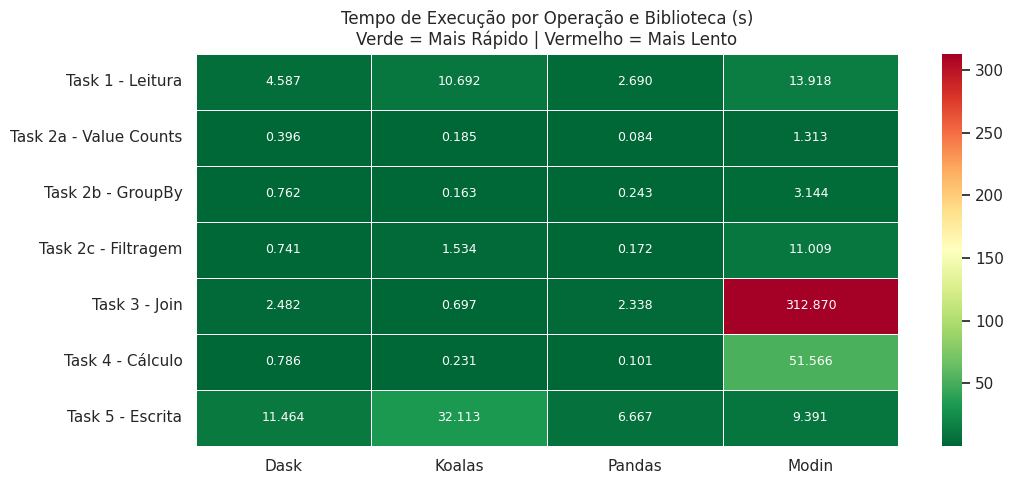

 Guardado: heatmap_exp1modin.png


In [42]:
# ── Heatmap Visual (MODIFICADO — adicionada coluna Modin) ───
fig, ax = plt.subplots(figsize=(11, 5))
cols_num = [c for c in tabela_pivot.columns if c not in [' Vencedor'] and 'Ratio' not in c]
dados_heat = tabela_pivot[cols_num].fillna(tabela_pivot[cols_num].max().max())
sns.heatmap(dados_heat, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Tempo de Execução por Operação e Biblioteca (s)\nVerde = Mais Rápido | Vermelho = Mais Lento', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('./heatmap_exp1modin.png', dpi=150)
plt.show()
print(" Guardado: heatmap_exp1modin.png")

O Modin apresenta um comportamento inconsistente ao longo das diferentes tarefas, variando entre bom desempenho em operações simples e desempenho significativamente inferior em operações mais complexas ou dependentes de I/O.

Globalmente, o Modin não substitui o Pandas em todos os cenários, mas funciona como uma solução de aceleração “transparente” que só apresenta vantagens em operações específicas e altamente paralelizáveis.

O próximo passo será passar para DaskModin, uma tentativa de juncao de Dask com Modin.


**Próximo Notebook:**

 2.1-experimento_DaskModin.ipynb - Combinação Modin + Dask